# 🚀 Notebook 3 v2 — Two-Track Training: LSTM Ablation + ClipCap

This notebook trains and evaluates **eight** models in total, organised in two parallel ablation tracks. Both tracks share the same data, the same eval, and the same emotion-conditioning conceptual variants — so you get directly comparable findings.

## Track A — LSTM ablation (4 models)

Faithful to the original proposal. From-scratch decoder, no pretrained text component.

| | Emotion conditioning | Visual conditioning |
|---|---|---|
| **A1** Baseline | none | CLS token |
| **A2** Emotion@Start | concatenated into LSTM `h0` | CLS token |
| **A3** Emotion@Every | concatenated to word embedding each step | CLS token |
| **A4** CrossAttention | concatenated into `h0` | spatial cross-attention over 49 patches |

## Track B — ClipCap ablation (4 models, GPT-2 + LoRA)

Same four conditioning variants, expressed as different ways to fold visual + emotion into a *prefix* prepended to a frozen GPT-2's input embeddings. LoRA adapters on attention layers (~1 M trainable params).

| | Prefix structure |
|---|---|
| **B1** Baseline | visual prefix only |
| **B2** Emotion@Start | `[emotion, visual]` prefix |
| **B3** Emotion@Every | emotion broadcast to every prefix slot |
| **B4** CrossAttention | mapping network with emotion as cross-attention query |

## Why two tracks

- **Track A** stays loyal to the proposal's ablation design and shows you understand how to build a captioner from scratch.
- **Track B** gives you at least one model that **actually produces grammatical, grounded captions** — because GPT-2 already speaks English and you only need to teach it what the picture is and what mood to use.

The report writes itself: *"Track A's ablation shows emotion@start/every consistently beat baseline by ΔBLEU=X. Track B replicates the same ordering at much higher absolute BLEU and with grammatical English, validating the ablation design while overcoming the from-scratch decoder's grammar limitations."*

## Inputs (from Notebook 2)

- `processed_captions.pkl` — captions tokenized into reduced LOCAL vocab (used by Track A only)
- `vocab_mapping.pkl` — local↔CLIP id map (Track A only)
- `train.csv`, `val.csv`, `test.csv` — splits with raw text (used by both tracks; Track B uses the raw text directly with GPT-2's tokenizer)
- Flickr8k images mounted as a Kaggle dataset

## Wall time on T4×2

Stage A (LSTM neutral pretrain) ~25 min · Stage B (LSTM 4 variants × 20 epochs) ~2 h · ClipCap (4 variants × 8 epochs) ~3 h · BLEU eval (8 models × test set) ~1 h.   **Budget ~6–7 h.**


## ⚙️ Step 1: Setup + Hyperparameters

In [1]:
import os, time, json, pickle, random, math, gc
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm.auto import tqdm

# ── Determinism ──────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False    # set True if exact reproducibility matters more than speed
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpu  = torch.cuda.device_count()
print(f"Device      : {device}")
print(f"GPUs visible: {n_gpu}")
for i in range(n_gpu):
    print(f"  cuda:{i}    : {torch.cuda.get_device_name(i)} ({torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB)")

# ── Paths — UPDATE these to wherever Notebook 2's outputs are mounted ────────
WORKING_DIR    = '/kaggle/working'
FEATURE_DIR    = f'{WORKING_DIR}/clip_features'
os.makedirs(FEATURE_DIR, exist_ok=True)

# Notebook 2 outputs (mount as a Kaggle dataset and update this path)
TOKENIZED_DIR  = '/kaggle/input/datasets/muhammadasjadali/tokenized8k'    # ← UPDATE
SPLIT_DIR      = TOKENIZED_DIR
CAPTIONS_PKL   = f'{TOKENIZED_DIR}/processed_captions.pkl'
VOCAB_PKL      = f'{TOKENIZED_DIR}/vocab_mapping.pkl'

# Flickr8k images
IMG_BASE_DIR   = '/kaggle/input/datasets/adityajn105/flickr8k/Images'

# ── Track A (LSTM) hyperparameters ───────────────────────────────────────────
LSTM_HIDDEN_DIM   = 384
LSTM_WORD_DIM     = 384       # equal to HIDDEN for weight tying without extra projection
LSTM_EMO_DIM      = 64
VISUAL_DIM        = 768       # CLIP ViT-B/32 patch dim
LSTM_EMBED_DROP   = 0.5
LSTM_DROP         = 0.4
N_EMOTIONS        = 5

LSTM_BATCH_SIZE   = 64
STAGE_A_EPOCHS    = 25
STAGE_B_EPOCHS    = 20
WARMUP_EPOCHS     = 3
LSTM_LR_STAGE_A   = 5e-4
LSTM_LR_STAGE_B   = 2e-4
WEIGHT_DECAY      = 1e-4
GRAD_CLIP         = 5.0
ES_PATIENCE       = 5
LABEL_SMOOTHING   = 0.1

# ── Track B (ClipCap + GPT-2) hyperparameters ────────────────────────────────
GPT2_MODEL_NAME   = 'gpt2'      # 124 M params — fits comfortably on a single T4
PREFIX_LEN        = 10          # visual prefix length (number of "soft tokens")
CC_BATCH_SIZE     = 32          # smaller because GPT-2 forward is heavier
CC_EPOCHS         = 8
CC_LR             = 5e-4        # for LoRA + projector params (GPT-2 itself frozen)
LORA_R            = 8
LORA_ALPHA        = 16
LORA_DROPOUT      = 0.05

print("✅ Setup ok")


Device      : cuda
GPUs visible: 2
  cuda:0    : Tesla T4 (15.6 GB)
  cuda:1    : Tesla T4 (15.6 GB)
✅ Setup ok


## 📚 Step 2: Load Vocab Mapping & Decoder Utilities

In [2]:
with open(VOCAB_PKL, 'rb') as f:
    V = pickle.load(f)

VOCAB_SIZE   = V['vocab_size']
PAD_ID       = V['pad_id']
SOS_ID       = V['sos_id']
EOS_ID       = V['eos_id']
UNK_ID       = V['unk_id']
MAX_SEQ_LEN  = V['max_seq_len']
EMOTIONS     = V['emotions']
EMOTION2ID   = {e: i for i, e in enumerate(EMOTIONS)}
local2clip   = V['local2clip']
clip2local   = V['clip2local']

# CLIP tokenizer — used to decode Track A's local-id outputs back to text
from transformers import CLIPTokenizer
clip_tokenizer = CLIPTokenizer.from_pretrained('openai/clip-vit-base-patch32')
clip_tokenizer.add_special_tokens({'pad_token': '[PAD]'})

def local_ids_to_text(local_ids):
    """Decode list of LOCAL ids → readable string. Stops at EOS, skips SOS/PAD/UNK."""
    clip_ids = []
    for lid in local_ids:
        lid = int(lid)
        if lid == EOS_ID or lid == PAD_ID:
            break
        if lid in (SOS_ID, UNK_ID):
            continue
        cid = local2clip.get(lid)
        if cid is not None:
            clip_ids.append(cid)
    return clip_tokenizer.decode(clip_ids).strip()

print(f"Track A vocab : {VOCAB_SIZE:,} tokens "
      f"(PAD={PAD_ID} SOS={SOS_ID} EOS={EOS_ID} UNK={UNK_ID})")
print(f"Emotions      : {EMOTIONS}")
print(f"Decode test   : {local_ids_to_text([SOS_ID, 100, 101, 102, EOS_ID])!r}")


tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Track A vocab : 9,199 tokens (PAD=0 SOS=1 EOS=2 UNK=3)
Emotions      : ['humorous', 'joyful', 'romantic', 'sad', 'tense']
Decode test   : 'wooden jumping beach'


## 🖼️ Step 3: CLIP Visual Feature Pre-Extraction

Run once per Kaggle session. Each image becomes a `(50, 768)` tensor — 49 patch tokens + 1 CLS. After extraction the CLIP model is freed.

In [3]:
from transformers import CLIPProcessor, CLIPVisionModel

CLIP_MODEL_NAME = 'openai/clip-vit-base-patch32'

clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_vision    = CLIPVisionModel.from_pretrained(CLIP_MODEL_NAME).to(device).eval()

# Need features for every image referenced by any split
train_df = pd.read_csv(f'{SPLIT_DIR}/train.csv')
val_df   = pd.read_csv(f'{SPLIT_DIR}/val.csv')
test_df  = pd.read_csv(f'{SPLIT_DIR}/test.csv')
all_imgs = pd.concat([train_df, val_df, test_df]).drop_duplicates('image_id')

print(f"Need features for {len(all_imgs):,} unique images")
missing = []
for img_id in all_imgs['image_id'].unique():
    pt = os.path.join(FEATURE_DIR, f"{img_id.rsplit('.', 1)[0]}.pt")
    if not os.path.exists(pt):
        missing.append(img_id)
print(f"Already done : {len(all_imgs) - len(missing):,}")
print(f"To extract   : {len(missing):,}")

with torch.no_grad():
    for img_id in tqdm(missing, desc='CLIP feature extraction'):
        try:
            img = Image.open(os.path.join(IMG_BASE_DIR, img_id)).convert('RGB')
            inp = clip_processor(images=img, return_tensors='pt').to(device)
            out = clip_vision(**inp)
            feat = out.last_hidden_state.cpu().squeeze(0)        # (50, 768)
            torch.save(feat, os.path.join(FEATURE_DIR,
                       f"{img_id.rsplit('.', 1)[0]}.pt"))
        except Exception as e:
            print(f"  ⚠ {img_id}: {e}")

del clip_vision, clip_processor
torch.cuda.empty_cache(); gc.collect()
print("✅ CLIP features ready, GPU cleared")


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias      

Need features for 7,762 unique images
Already done : 7,762
To extract   : 0


CLIP feature extraction: 0it [00:00, ?it/s]

✅ CLIP features ready, GPU cleared


## 📦 Step 4: Datasets & DataLoaders for Track A

Track A uses LOCAL token ids (the reduced ~5K vocab from Notebook 2). We provide loaders for both Stage A (neutral target) and Stage B (emotion target).

In [4]:
# Load tokenized captions for Track A
with open(CAPTIONS_PKL, 'rb') as f:
    all_processed = pickle.load(f)
print(f"Total tokenized rows: {len(all_processed):,}")

by_split = {'train': [], 'val': [], 'test': []}
for p in all_processed:
    by_split[p['split']].append(p)
for s in by_split:
    print(f"  {s:5s}: {len(by_split[s]):,}")


# ════════════════════════════════════════════════════════════════════════════
# Track A dataset — uses LOCAL token ids
# ════════════════════════════════════════════════════════════════════════════
class CaptionDatasetLocal(Dataset):
    """Serves (visual_features, local_token_ids, emotion_id).
    target='emotion' → emotion_local_token_ids
    target='neutral' → neutral_local_token_ids (deduplicated by image_id)
    """
    def __init__(self, entries, feature_dir, target='emotion'):
        assert target in ('emotion', 'neutral')
        self.target = target
        self.feature_dir = feature_dir

        if target == 'neutral':
            seen = set()
            entries = [e for e in entries if not (e['image_id'] in seen or seen.add(e['image_id']))]
        self.entries = entries

        self.feat_cache = {}
        miss = 0
        for img_id in {e['image_id'] for e in self.entries}:
            p = os.path.join(feature_dir, f"{img_id.rsplit('.', 1)[0]}.pt")
            if os.path.exists(p):
                self.feat_cache[img_id] = torch.load(p, weights_only=True)
            else:
                miss += 1
        if miss:
            print(f"  ⚠ {miss} feature files missing")

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, i):
        e = self.entries[i]
        vis = self.feat_cache[e['image_id']]
        ids = e['neutral_local_token_ids'] if self.target == 'neutral' else e['emotion_local_token_ids']
        return vis, torch.tensor(ids, dtype=torch.long), torch.tensor(e['emotion_id'], dtype=torch.long)


def collate_local(batch):
    vis, caps, emos = zip(*batch)
    max_len = max(c.size(0) for c in caps)
    padded = torch.full((len(caps), max_len), PAD_ID, dtype=torch.long)
    for i, c in enumerate(caps):
        padded[i, :c.size(0)] = c
    return torch.stack(vis), padded, torch.stack(emos)


# Track A loaders
ds_A_train = CaptionDatasetLocal(by_split['train'], FEATURE_DIR, target='neutral')
ds_A_val   = CaptionDatasetLocal(by_split['val'],   FEATURE_DIR, target='neutral')
ds_B_train = CaptionDatasetLocal(by_split['train'], FEATURE_DIR, target='emotion')
ds_B_val   = CaptionDatasetLocal(by_split['val'],   FEATURE_DIR, target='emotion')

mk = lambda ds, shuf, bs: DataLoader(ds, batch_size=bs, shuffle=shuf,
                                      num_workers=2, pin_memory=True,
                                      collate_fn=collate_local, drop_last=shuf)
loader_A_train = mk(ds_A_train, True,  LSTM_BATCH_SIZE)
loader_A_val   = mk(ds_A_val,   False, LSTM_BATCH_SIZE)
loader_B_train = mk(ds_B_train, True,  LSTM_BATCH_SIZE)
loader_B_val   = mk(ds_B_val,   False, LSTM_BATCH_SIZE)

print(f"\nTrack A — Stage A (neutral)  : train={len(ds_A_train):,}  val={len(ds_A_val):,}")
print(f"Track A — Stage B (emotion)    : train={len(ds_B_train):,}  val={len(ds_B_val):,}")


Total tokenized rows: 36,910
  train: 29,486
  val  : 3,702
  test : 3,722

Track A — Stage A (neutral)  : train=6,209  val=776
Track A — Stage B (emotion)    : train=29,486  val=3,702


In [5]:
# ════════════════════════════════════════════════════════════════════════════
# Pre-flight check — find any out-of-range token IDs before training starts.
# Catches the most common cause of asynchronous CUDA device-side asserts.
# ════════════════════════════════════════════════════════════════════════════
import numpy as np

print(f"VOCAB_SIZE  = {VOCAB_SIZE}")
print(f"PAD={PAD_ID}  SOS={SOS_ID}  EOS={EOS_ID}  UNK={UNK_ID}\n")

issues = 0
for label, ds in [('Stage A train', ds_A_train), ('Stage A val', ds_A_val),
                  ('Stage B train', ds_B_train), ('Stage B val', ds_B_val)]:
    max_id = -1
    min_id = 1e9
    bad_rows = 0
    for i in range(len(ds)):
        e = ds.entries[i]
        ids = (e['neutral_local_token_ids'] if ds.target == 'neutral'
                                            else e['emotion_local_token_ids'])
        m = max(ids); n = min(ids)
        if m >= VOCAB_SIZE or n < 0:
            bad_rows += 1
            if bad_rows <= 3:
                print(f"  ⚠ {label} row {i} ({e['image_id']}, {e['emotion']}): "
                      f"min={n} max={m}  ids={ids[:10]}...")
        if m > max_id: max_id = m
        if n < min_id: min_id = n
    status = "✅" if bad_rows == 0 else f"❌ {bad_rows} bad rows"
    print(f"  {label:18s}  range=[{min_id}, {max_id}]   {status}")
    issues += bad_rows

# Same for emotion ids (must be < N_EMOTIONS)
all_emo = []
for ds in [ds_A_train, ds_A_val, ds_B_train, ds_B_val]:
    all_emo.extend(e['emotion_id'] for e in ds.entries)
emo_max = max(all_emo); emo_min = min(all_emo)
emo_bad = sum(1 for e in all_emo if e >= N_EMOTIONS or e < 0)
print(f"\n  emotion_id range=[{emo_min}, {emo_max}]  N_EMOTIONS={N_EMOTIONS}  "
      f"{'✅' if emo_bad == 0 else f'❌ {emo_bad} bad'}")

assert issues == 0,  f"Found {issues} rows with out-of-range token IDs — see above"
assert emo_bad == 0, "Found out-of-range emotion IDs"
print("\n✅ Data sanity check passed — safe to start training")

VOCAB_SIZE  = 9199
PAD=0  SOS=1  EOS=2  UNK=3

  Stage A train       range=[1, 8542]   ✅
  Stage A val         range=[1, 7601]   ✅
  ⚠ Stage B train row 28369 (61209225_8512e1dad5.jpg, joyful): min=1 max=9199  ids=[1, 2222, 2643, 68, 83, 5, 3243, 1812, 285, 9199]...
  ⚠ Stage B train row 28372 (61209225_8512e1dad5.jpg, romantic): min=1 max=9199  ids=[1, 10, 5, 51, 40, 7, 5, 3243, 1812, 285]...
  Stage B train       range=[1, 9199]   ❌ 2 bad rows
  Stage B val         range=[1, 9191]   ✅

  emotion_id range=[0, 4]  N_EMOTIONS=5  ✅


AssertionError: Found 2 rows with out-of-range token IDs — see above

In [7]:
# ════════════════════════════════════════════════════════════════════════════
# Patch out-of-range token IDs in-place. Replaces any id >= VOCAB_SIZE with UNK.
# Safe: it only touches ids that are already broken.
# ════════════════════════════════════════════════════════════════════════════
fixed_count = 0
fixed_rows  = 0

for ds in [ds_A_train, ds_A_val, ds_B_train, ds_B_val]:
    for e in ds.entries:
        for key in ['neutral_local_token_ids', 'emotion_local_token_ids']:
            ids = e[key]
            bad = [i for i, t in enumerate(ids) if t >= VOCAB_SIZE or t < 0]
            if bad:
                e[key] = [UNK_ID if (t >= VOCAB_SIZE or t < 0) else t for t in ids]
                fixed_count += len(bad)
                fixed_rows  += 1

print(f"Patched {fixed_count} bad token IDs across {fixed_rows} rows "
      f"(replaced with UNK={UNK_ID})")

# Re-run the pre-flight to confirm
issues = 0
for label, ds in [('Stage A train', ds_A_train), ('Stage A val', ds_A_val),
                  ('Stage B train', ds_B_train), ('Stage B val', ds_B_val)]:
    max_id = max(t for e in ds.entries
                   for t in (e['neutral_local_token_ids']
                             if ds.target == 'neutral'
                             else e['emotion_local_token_ids']))
    min_id = min(t for e in ds.entries
                   for t in (e['neutral_local_token_ids']
                             if ds.target == 'neutral'
                             else e['emotion_local_token_ids']))
    bad = (max_id >= VOCAB_SIZE) or (min_id < 0)
    print(f"  {label:18s}  range=[{min_id}, {max_id}]   "
          f"{'❌' if bad else '✅'}")
    if bad: issues += 1

assert issues == 0, "Still bad after patch — rerun Notebook 2"
print("\n✅ Safe to train")

Patched 0 bad token IDs across 0 rows (replaced with UNK=3)
  Stage A train       range=[1, 8542]   ✅
  Stage A val         range=[1, 7601]   ✅
  Stage B train       range=[1, 9198]   ✅
  Stage B val         range=[1, 9191]   ✅

✅ Safe to train


## 🅰 Track A — LSTM Ablation (4 from-scratch decoders)

Each variant implements three methods so we can share one beam-search routine:
- `forward(vf, captions, emo_ids)` — teacher-forced training; returns logits `(B, T-1, V)`
- `init_state(vf, emo_id)` — returns a state dict for inference
- `step(token, state)` — one decoding step; returns `(logits[B,V], new_state)`

All four use **weight tying** between the input word embedding and the output projection. With `WORD_DIM == HIDDEN_DIM == 384`, no extra projection is needed.


### Architectures

In [8]:
def _make_embedding():
    return nn.Embedding(VOCAB_SIZE, LSTM_WORD_DIM, padding_idx=PAD_ID)


class TiedFC(nn.Module):
    """Linear layer whose weight is tied to a given embedding."""
    def __init__(self, embed: nn.Embedding):
        super().__init__()
        self.embed = embed
        self.bias  = nn.Parameter(torch.zeros(embed.num_embeddings))

    def forward(self, x):
        return F.linear(x, self.embed.weight, self.bias)


# ════════════════════════════════════════════════════════════════════════════
# A1. BASELINE — visual CLS only, no emotion
# ════════════════════════════════════════════════════════════════════════════
class BaselineCaptioner(nn.Module):
    def __init__(self):
        super().__init__()
        self.vis_proj   = nn.Sequential(nn.Linear(VISUAL_DIM, LSTM_HIDDEN_DIM), nn.ReLU())
        self.embed      = _make_embedding()
        self.embed_drop = nn.Dropout(LSTM_EMBED_DROP)
        self.lstm       = nn.LSTM(LSTM_WORD_DIM, LSTM_HIDDEN_DIM, batch_first=True)
        self.lstm_drop  = nn.Dropout(LSTM_DROP)
        self.fc_out     = TiedFC(self.embed)

    def forward(self, vf, caps, _emo=None):
        h0 = self.vis_proj(vf[:, 0, :]).unsqueeze(0)
        c0 = torch.zeros_like(h0)
        emb = self.embed_drop(self.embed(caps[:, :-1]))
        out, _ = self.lstm(emb, (h0, c0))
        return self.fc_out(self.lstm_drop(out))

    def init_state(self, vf, _emo=None):
        h = self.vis_proj(vf[:, 0, :]).unsqueeze(0)
        c = torch.zeros_like(h)
        return {'h': h, 'c': c}

    def step(self, token, state):
        emb = self.embed(token).unsqueeze(1)
        out, (h, c) = self.lstm(emb, (state['h'], state['c']))
        return self.fc_out(out.squeeze(1)), {'h': h, 'c': c}


# ════════════════════════════════════════════════════════════════════════════
# A2. EMOTION@START — emotion fused into h0 only
# ════════════════════════════════════════════════════════════════════════════
class EmotionAtStartCaptioner(nn.Module):
    def __init__(self):
        super().__init__()
        self.emo_embed  = nn.Embedding(N_EMOTIONS, LSTM_EMO_DIM)
        self.vis_proj   = nn.Sequential(
            nn.Linear(VISUAL_DIM + LSTM_EMO_DIM, LSTM_HIDDEN_DIM), nn.ReLU()
        )
        self.embed      = _make_embedding()
        self.embed_drop = nn.Dropout(LSTM_EMBED_DROP)
        self.lstm       = nn.LSTM(LSTM_WORD_DIM, LSTM_HIDDEN_DIM, batch_first=True)
        self.lstm_drop  = nn.Dropout(LSTM_DROP)
        self.fc_out     = TiedFC(self.embed)

    def forward(self, vf, caps, emo_ids):
        emo = self.emo_embed(emo_ids)
        h0  = self.vis_proj(torch.cat([vf[:, 0, :], emo], -1)).unsqueeze(0)
        c0  = torch.zeros_like(h0)
        emb = self.embed_drop(self.embed(caps[:, :-1]))
        out, _ = self.lstm(emb, (h0, c0))
        return self.fc_out(self.lstm_drop(out))

    def init_state(self, vf, emo_id):
        emo = self.emo_embed(emo_id)
        h   = self.vis_proj(torch.cat([vf[:, 0, :], emo], -1)).unsqueeze(0)
        c   = torch.zeros_like(h)
        return {'h': h, 'c': c}

    def step(self, token, state):
        emb = self.embed(token).unsqueeze(1)
        out, (h, c) = self.lstm(emb, (state['h'], state['c']))
        return self.fc_out(out.squeeze(1)), {'h': h, 'c': c}


# ════════════════════════════════════════════════════════════════════════════
# A3. EMOTION@EVERY — emotion appended to word embed at every step
# ════════════════════════════════════════════════════════════════════════════
class EmotionAtEveryCaptioner(nn.Module):
    def __init__(self):
        super().__init__()
        self.emo_embed  = nn.Embedding(N_EMOTIONS, LSTM_EMO_DIM)
        self.vis_proj   = nn.Sequential(
            nn.Linear(VISUAL_DIM + LSTM_EMO_DIM, LSTM_HIDDEN_DIM), nn.ReLU()
        )
        self.embed      = _make_embedding()
        self.embed_drop = nn.Dropout(LSTM_EMBED_DROP)
        self.lstm       = nn.LSTM(LSTM_WORD_DIM + LSTM_EMO_DIM, LSTM_HIDDEN_DIM, batch_first=True)
        self.lstm_drop  = nn.Dropout(LSTM_DROP)
        self.fc_out     = TiedFC(self.embed)

    def forward(self, vf, caps, emo_ids):
        T   = caps.size(1) - 1
        emo = self.emo_embed(emo_ids)
        h0  = self.vis_proj(torch.cat([vf[:, 0, :], emo], -1)).unsqueeze(0)
        c0  = torch.zeros_like(h0)
        w   = self.embed_drop(self.embed(caps[:, :-1]))
        emo_r = emo.unsqueeze(1).expand(-1, T, -1)
        out, _ = self.lstm(torch.cat([w, emo_r], -1), (h0, c0))
        return self.fc_out(self.lstm_drop(out))

    def init_state(self, vf, emo_id):
        emo = self.emo_embed(emo_id)
        h   = self.vis_proj(torch.cat([vf[:, 0, :], emo], -1)).unsqueeze(0)
        c   = torch.zeros_like(h)
        return {'h': h, 'c': c, 'emo': emo}

    def step(self, token, state):
        w   = self.embed(token).unsqueeze(1)
        inp = torch.cat([w, state['emo'].unsqueeze(1)], -1)
        out, (h, c) = self.lstm(inp, (state['h'], state['c']))
        return self.fc_out(out.squeeze(1)), {'h': h, 'c': c, 'emo': state['emo']}


# ════════════════════════════════════════════════════════════════════════════
# A4. CROSSATTENTION — spatial attention over all 49 patches every step
# ════════════════════════════════════════════════════════════════════════════
class CrossAttnCaptioner(nn.Module):
    def __init__(self):
        super().__init__()
        self.emo_embed  = nn.Embedding(N_EMOTIONS, LSTM_EMO_DIM)
        self.init_proj  = nn.Sequential(
            nn.Linear(VISUAL_DIM + LSTM_EMO_DIM, LSTM_HIDDEN_DIM), nn.ReLU()
        )
        self.kv_proj    = nn.Linear(VISUAL_DIM, LSTM_HIDDEN_DIM)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=LSTM_HIDDEN_DIM, num_heads=8, dropout=0.1, batch_first=True
        )
        self.attn_norm  = nn.LayerNorm(LSTM_HIDDEN_DIM)
        self.embed      = _make_embedding()
        self.embed_drop = nn.Dropout(LSTM_EMBED_DROP)
        self.lstm_cell  = nn.LSTMCell(LSTM_WORD_DIM + LSTM_EMO_DIM, LSTM_HIDDEN_DIM)
        self.lstm_drop  = nn.Dropout(LSTM_DROP)
        self.fc_out     = TiedFC(self.embed)

    def _setup(self, vf, emo_ids):
        emo = self.emo_embed(emo_ids)
        h   = self.init_proj(torch.cat([vf[:, 0, :], emo], -1))
        c   = torch.zeros_like(h)
        kv  = self.kv_proj(vf)             # (B, 50, H)
        return h, c, kv, emo

    def forward(self, vf, caps, emo_ids):
        T = caps.size(1) - 1
        h, c, kv, emo = self._setup(vf, emo_ids)
        outs = []
        for t in range(T):
            w = self.embed_drop(self.embed(caps[:, t]))
            h, c = self.lstm_cell(torch.cat([w, emo], -1), (h, c))
            ha, _ = self.cross_attn(h.unsqueeze(1), kv, kv)
            ha    = self.attn_norm(h.unsqueeze(1) + ha).squeeze(1)
            ha    = self.lstm_drop(ha)
            outs.append(self.fc_out(ha))
        return torch.stack(outs, dim=1)

    def init_state(self, vf, emo_id):
        h, c, kv, emo = self._setup(vf, emo_id)
        return {'h': h, 'c': c, 'kv': kv, 'emo': emo}

    def step(self, token, state):
        w = self.embed(token)                                            # (B, W)
        h, c = self.lstm_cell(torch.cat([w, state['emo']], -1),
                              (state['h'], state['c']))
        ha, _ = self.cross_attn(h.unsqueeze(1), state['kv'], state['kv'])
        ha    = self.attn_norm(h.unsqueeze(1) + ha).squeeze(1)
        return self.fc_out(ha), {'h': h, 'c': c, 'kv': state['kv'], 'emo': state['emo']}


def _count(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
print("Track A architectures (parameter counts):")
for cls in [BaselineCaptioner, EmotionAtStartCaptioner, EmotionAtEveryCaptioner, CrossAttnCaptioner]:
    print(f"  {cls.__name__:30s}: {_count(cls()):>9,}")


Track A architectures (parameter counts):
  BaselineCaptioner             : 5,019,631
  EmotionAtStartCaptioner       : 5,044,527
  EmotionAtEveryCaptioner       : 5,142,831
  CrossAttnCaptioner            : 6,030,255


### Training engine

In [9]:
def _set_lr(opt, lr):
    for g in opt.param_groups:
        g['lr'] = lr


def make_optimizer_and_sched(model, base_lr, n_epochs, warmup):
    no_decay = ['bias', 'LayerNorm.weight', 'norm.weight', 'attn_norm.weight']
    decay = [p for n, p in model.named_parameters()
             if p.requires_grad and not any(nd in n for nd in no_decay)]
    nodecay = [p for n, p in model.named_parameters()
               if p.requires_grad and any(nd in n for nd in no_decay)]
    opt = torch.optim.AdamW([
        {'params': decay,   'weight_decay': WEIGHT_DECAY},
        {'params': nodecay, 'weight_decay': 0.0}
    ], lr=base_lr)
    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=max(1, n_epochs - warmup), eta_min=base_lr * 0.05
    )
    return opt, cosine


def run_epoch_lstm(model, loader, opt, criterion, train=True):
    model.train() if train else model.eval()
    tot, n = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for vf, caps, emos in loader:
            vf, caps, emos = vf.to(device), caps.to(device), emos.to(device)
            logits  = model(vf, caps, emos)
            targets = caps[:, 1:].reshape(-1)
            loss    = criterion(logits.reshape(-1, VOCAB_SIZE), targets)
            if train:
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                opt.step()
            tot += loss.item() * vf.size(0)
            n   += vf.size(0)
    return tot / n


def train_lstm(model, name, train_loader, val_loader,
               base_lr, n_epochs, warmup_epochs):
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=LABEL_SMOOTHING)
    opt, cosine = make_optimizer_and_sched(model, base_lr, n_epochs, warmup_epochs)

    ckpt = os.path.join(WORKING_DIR, f'{name}_best.pt')
    best, es = float('inf'), 0
    history = {'train': [], 'val': [], 'lr': []}

    print(f"\n════ {name} ({_count(model):,} params, lr={base_lr:.0e}, {n_epochs} ep) ════")
    for ep in range(1, n_epochs + 1):
        if ep <= warmup_epochs:
            _set_lr(opt, base_lr * ep / warmup_epochs)
        t0 = time.time()
        tr = run_epoch_lstm(model, train_loader, opt, criterion, train=True)
        va = run_epoch_lstm(model, val_loader,   opt, criterion, train=False)
        if ep > warmup_epochs:
            cosine.step()
        lr = opt.param_groups[0]['lr']
        history['train'].append(tr); history['val'].append(va); history['lr'].append(lr)
        gap = va - tr; flag = '⚠' if gap > 0.6 else ' '
        print(f"  Ep {ep:2d}/{n_epochs}  train={tr:.4f}  val={va:.4f}  "
              f"gap={gap:+.4f}{flag}  lr={lr:.2e}  [{time.time()-t0:.0f}s]")

        if va < best:
            best, es = va, 0
            torch.save(model.state_dict(), ckpt)
        else:
            es += 1
            if es >= ES_PATIENCE:
                print(f"  ⏹  Early stop at ep {ep}"); break

    model.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
    print(f"  ✅ {name} — best val = {best:.4f}")
    return model, history


### Beam search decoder for Track A

In [10]:
@torch.no_grad()
def beam_search_lstm(model, vf, emo_id, beam_size=4, max_len=MAX_SEQ_LEN,
                     length_alpha=0.7, no_repeat_ngram=3, min_len=5):
    """Beam search for Track A. vf: (1, 50, 768)  emo_id: (1,)
    Returns best decoded LOCAL token list (excluding SOS)."""
    model.eval()
    assert vf.size(0) == 1

    init = model.init_state(vf, emo_id)
    beams = [(0.0, [SOS_ID], init)]
    completed = []

    def length_norm(score, length):
        return score / (((5 + length) ** length_alpha) / ((5 + 1) ** length_alpha))

    for step_i in range(max_len):
        new_beams = []
        for score, toks, state in beams:
            if toks[-1] == EOS_ID:
                completed.append((score, toks))
                continue
            tok_t = torch.tensor([toks[-1]], device=device, dtype=torch.long)
            logits, new_state = model.step(tok_t, state)
            log_p = F.log_softmax(logits, dim=-1).squeeze(0).clone()

            # Block bad tokens
            log_p[UNK_ID] = -1e9
            log_p[SOS_ID] = -1e9
            log_p[PAD_ID] = -1e9
            if step_i < min_len:
                log_p[EOS_ID] = -1e9

            # No-repeat n-gram blocking
            if no_repeat_ngram > 0 and len(toks) >= no_repeat_ngram:
                prefix = tuple(toks[-(no_repeat_ngram - 1):])
                for i in range(len(toks) - no_repeat_ngram + 1):
                    if tuple(toks[i:i + no_repeat_ngram - 1]) == prefix:
                        log_p[toks[i + no_repeat_ngram - 1]] = -1e9

            topk_lp, topk_idx = log_p.topk(beam_size)
            for lp, idx in zip(topk_lp.tolist(), topk_idx.tolist()):
                new_beams.append((score + lp, toks + [idx], new_state))

        new_beams.sort(key=lambda b: -length_norm(b[0], len(b[1])))
        beams = new_beams[:beam_size]

        if all(b[1][-1] == EOS_ID for b in beams):
            for b in beams:
                completed.append((b[0], b[1]))
            break

    for score, toks, _ in beams:
        if (score, toks) not in completed:
            completed.append((score, toks))
    completed.sort(key=lambda b: -length_norm(b[0], len(b[1])))
    return completed[0][1][1:]   # drop SOS

print("✅ Track A beam search ready")


✅ Track A beam search ready


### 🏃 Stage A: pretrain Baseline on NEUTRAL captions

Teaches the visual→language pathway grounded captioning before any emotion conditioning. The resulting weights initialise all 4 Stage B variants where shapes match.

In [11]:
trained_models = {}      # holds final loaded checkpoints for ALL models from both tracks
histories = {}

# ── Stage A: pretrain Baseline on NEUTRAL captions ───────────────────────────
torch.manual_seed(SEED)
baseline_A = BaselineCaptioner().to(device)
baseline_A, hist_A = train_lstm(
    baseline_A, 'A0_LSTM_Baseline_StageA',
    loader_A_train, loader_A_val,
    base_lr=LSTM_LR_STAGE_A,
    n_epochs=STAGE_A_EPOCHS,
    warmup_epochs=WARMUP_EPOCHS
)
histories['A0_LSTM_Baseline_StageA'] = hist_A

STAGE_A_PATH = os.path.join(WORKING_DIR, 'A0_LSTM_Baseline_StageA_best.pt')
torch.save(baseline_A.state_dict(), STAGE_A_PATH)
print(f"\n📌 Stage A done. best_val={min(hist_A['val']):.4f}")
print(f"   Saved → {STAGE_A_PATH}")
del baseline_A; gc.collect(); torch.cuda.empty_cache()



════ A0_LSTM_Baseline_StageA (5,019,631 params, lr=5e-04, 25 ep) ════
  Ep  1/25  train=11.0148  val=6.2458  gap=-4.7689   lr=1.67e-04  [4s]
  Ep  2/25  train=6.8423  val=4.9308  gap=-1.9115   lr=3.33e-04  [3s]
  Ep  3/25  train=5.6298  val=4.4448  gap=-1.1850   lr=5.00e-04  [3s]
  Ep  4/25  train=5.0812  val=4.1925  gap=-0.8887   lr=4.98e-04  [3s]
  Ep  5/25  train=4.7813  val=4.0405  gap=-0.7408   lr=4.90e-04  [3s]
  Ep  6/25  train=4.5789  val=3.9292  gap=-0.6497   lr=4.79e-04  [3s]
  Ep  7/25  train=4.4352  val=3.8576  gap=-0.5776   lr=4.62e-04  [3s]
  Ep  8/25  train=4.3232  val=3.7817  gap=-0.5415   lr=4.42e-04  [3s]
  Ep  9/25  train=4.2260  val=3.7225  gap=-0.5034   lr=4.18e-04  [3s]
  Ep 10/25  train=4.1531  val=3.6717  gap=-0.4814   lr=3.91e-04  [3s]
  Ep 11/25  train=4.0867  val=3.6385  gap=-0.4482   lr=3.61e-04  [3s]
  Ep 12/25  train=4.0383  val=3.5997  gap=-0.4386   lr=3.29e-04  [3s]
  Ep 13/25  train=3.9837  val=3.5726  gap=-0.4111   lr=2.96e-04  [3s]
  Ep 14/25  train=

### 🏃 Stage B: fine-tune all 4 LSTM variants on EMOTION captions

Each variant gets a Stage-A weight transfer for layers it shares. CrossAttention uses a smaller LR + longer warmup because it's the hardest variant.

In [ ]:
def transfer_from_stage_A(model, stage_a_state):
    """Copy parameter tensors from Stage-A checkpoint where shapes match."""
    own = model.state_dict()
    transferred, skipped = [], []
    for k, v in stage_a_state.items():
        if k in own and own[k].shape == v.shape:
            own[k] = v.clone()
            transferred.append(k)
        else:
            skipped.append(k)
    model.load_state_dict(own)
    print(f"   transferred {len(transferred)} tensors (skipped {len(skipped)})")


LSTM_ARCHS = {
    'A1_LSTM_Baseline'       : BaselineCaptioner,
    'A2_LSTM_EmotionAtStart' : EmotionAtStartCaptioner,
    'A3_LSTM_EmotionAtEvery' : EmotionAtEveryCaptioner,
    'A4_LSTM_CrossAttention' : CrossAttnCaptioner,
}

stage_a_state = torch.load(STAGE_A_PATH, map_location=device, weights_only=True)

for name, cls in LSTM_ARCHS.items():
    torch.manual_seed(SEED)
    model = cls().to(device)
    print(f"\n╔══════ Stage B: {name} ══════╗")
    transfer_from_stage_A(model, stage_a_state)

    # CrossAttention is the hardest variant — give it lower LR + longer warmup
    if 'CrossAttention' in name:
        lr     = LSTM_LR_STAGE_B * 0.5
        warmup = WARMUP_EPOCHS + 2
    else:
        lr     = LSTM_LR_STAGE_B
        warmup = WARMUP_EPOCHS

    model, hist = train_lstm(
        model, name,
        loader_B_train, loader_B_val,
        base_lr=lr,
        n_epochs=STAGE_B_EPOCHS,
        warmup_epochs=warmup
    )
    trained_models[name] = model
    histories[name] = hist

    # Free intermediate state, keep just the trained model on CPU between tracks
    gc.collect(); torch.cuda.empty_cache()

print("\n🎉 Track A — all 4 LSTM variants trained")



╔══════ Stage B: A1_LSTM_Baseline ══════╗
   transferred 9 tensors (skipped 0)

════ A1_LSTM_Baseline (5,019,631 params, lr=2e-04, 20 ep) ════
  Ep  1/20  train=6.9108  val=6.1570  gap=-0.7538   lr=6.67e-05  [13s]
  Ep  2/20  train=6.4066  val=5.8469  gap=-0.5597   lr=1.33e-04  [13s]
  Ep  3/20  train=6.1152  val=5.6329  gap=-0.4823   lr=2.00e-04  [12s]
  Ep  4/20  train=5.9285  val=5.5091  gap=-0.4193   lr=1.98e-04  [12s]
  Ep  5/20  train=5.8055  val=5.4226  gap=-0.3829   lr=1.94e-04  [12s]
  Ep  6/20  train=5.7175  val=5.3612  gap=-0.3563   lr=1.86e-04  [12s]
  Ep  7/20  train=5.6498  val=5.3089  gap=-0.3409   lr=1.75e-04  [12s]
  Ep  8/20  train=5.5935  val=5.2696  gap=-0.3239   lr=1.62e-04  [12s]


## 🅱 Track B — ClipCap with GPT-2 + LoRA

The decoder is a frozen `gpt2` (124 M params, English-grammatical out of the box). Only the following are trainable:

1. **Visual projector** — maps `(50, 768)` CLIP patches → `(PREFIX_LEN, 768)` "soft tokens" in GPT-2's embedding space.
2. **Emotion embedding** — same `nn.Embedding(5, 64)` as Track A.
3. **LoRA adapters** on GPT-2's attention layers (`r=8`, ~1 M params total).

We **prepend** the prefix to GPT-2's input embeddings and let GPT-2 generate. The four ablation variants differ in how the emotion is folded into the prefix — directly mirroring Track A's four conditioning strategies, but at the prefix level instead of at the LSTM level.

| Variant | Prefix structure |
|---|---|
| **B1** Baseline | `[v_1, v_2, ..., v_PREFIX_LEN]` — visual only |
| **B2** Emotion@Start | `[e_emo, v_1, ..., v_PREFIX_LEN]` — emotion as 1st soft token |
| **B3** Emotion@Every | `[v_1+e, v_2+e, ..., v_PREFIX_LEN+e]` — emotion broadcast over all soft tokens |
| **B4** CrossAttention | A small MLP-Mixer maps visual + emotion into the prefix via cross-attention |

This way the ablation compares **how** emotion is conditioned, not **whether** the architecture can speak English. GPT-2 handles grammar; the prefix handles content + tone.


### Install dependencies (one-time per Kaggle session)

In [13]:
!pip install -q peft==0.13.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 7.1 MB/s eta 0:00:0000:01


### Tokenizer & GPT-2 sanity check

In [14]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from peft import LoraConfig, get_peft_model, TaskType

gpt2_tokenizer = GPT2Tokenizer.from_pretrained(GPT2_MODEL_NAME)
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token   # GPT-2 has no PAD by default

GPT2_PAD_ID = gpt2_tokenizer.pad_token_id    # = eos_token_id (50256)
GPT2_EOS_ID = gpt2_tokenizer.eos_token_id
GPT2_BOS_ID = gpt2_tokenizer.bos_token_id    # 50256 — GPT-2 also reuses eos for bos
GPT2_VOCAB  = gpt2_tokenizer.vocab_size      # 50257

# What GPT-2 hidden dim is — we project visual features into this
GPT2_HIDDEN = GPT2LMHeadModel.from_pretrained(GPT2_MODEL_NAME).config.n_embd  # 768
gc.collect()
print(f"GPT-2     : {GPT2_MODEL_NAME}, vocab={GPT2_VOCAB:,}, hidden={GPT2_HIDDEN}")
print(f"  PAD={GPT2_PAD_ID}  EOS={GPT2_EOS_ID}  BOS={GPT2_BOS_ID}")


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT-2     : gpt2, vocab=50,257, hidden=768
  PAD=50256  EOS=50256  BOS=50256


### Track B dataset & loaders (uses GPT-2's tokenizer directly)

In [15]:
class CaptionDatasetGPT2(Dataset):
    """Dataset for Track B. Returns (visual_features, gpt2_input_ids, gpt2_attn_mask, emotion_id, target_text).
    The captions are tokenized with GPT-2's tokenizer here (not the local CLIP-derived one).
    """
    def __init__(self, entries, feature_dir, tokenizer, max_len=40):
        self.entries     = entries
        self.feature_dir = feature_dir
        self.tokenizer   = tokenizer
        self.max_len     = max_len

        self.feat_cache = {}
        for img_id in {e['image_id'] for e in entries}:
            p = os.path.join(feature_dir, f"{img_id.rsplit('.', 1)[0]}.pt")
            if os.path.exists(p):
                self.feat_cache[img_id] = torch.load(p, weights_only=True)

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, i):
        e = self.entries[i]
        vis = self.feat_cache[e['image_id']]
        text = e['emotion_caption'].strip()
        if not text.endswith(('.', '!', '?')):
            text += '.'
        # Add EOS so GPT-2 learns when to stop
        ids = self.tokenizer.encode(' ' + text, add_special_tokens=False)[: self.max_len - 1]
        ids = ids + [GPT2_EOS_ID]
        return (
            vis,
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(e['emotion_id'], dtype=torch.long),
            text,
        )


def collate_gpt2(batch):
    vis, ids, emos, texts = zip(*batch)
    max_len = max(t.size(0) for t in ids)
    padded = torch.full((len(ids), max_len), GPT2_PAD_ID, dtype=torch.long)
    mask   = torch.zeros((len(ids), max_len), dtype=torch.long)
    for i, t in enumerate(ids):
        padded[i, :t.size(0)] = t
        mask[i,   :t.size(0)] = 1
    return torch.stack(vis), padded, mask, torch.stack(emos), list(texts)


# Track B uses ALL train/val/test entries (it doesn't need the 'neutral' subset)
ds_CC_train = CaptionDatasetGPT2(by_split['train'], FEATURE_DIR, gpt2_tokenizer)
ds_CC_val   = CaptionDatasetGPT2(by_split['val'],   FEATURE_DIR, gpt2_tokenizer)

mk_cc = lambda ds, shuf: DataLoader(ds, batch_size=CC_BATCH_SIZE, shuffle=shuf,
                                     num_workers=2, pin_memory=True,
                                     collate_fn=collate_gpt2, drop_last=shuf)
loader_CC_train = mk_cc(ds_CC_train, True)
loader_CC_val   = mk_cc(ds_CC_val,   False)

print(f"Track B — GPT-2 tokenized: train={len(ds_CC_train):,}  val={len(ds_CC_val):,}")


Track B — GPT-2 tokenized: train=29,486  val=3,702


### Visual projector & cross-attention prefix builder

In [16]:
# Visual projector: (B, 50, 768) → (B, PREFIX_LEN, GPT2_HIDDEN)
class VisualPrefixProjector(nn.Module):
    """Two-layer MLP that maps the CLIP CLS token to a sequence of soft tokens."""
    def __init__(self, in_dim=VISUAL_DIM, out_dim=GPT2_HIDDEN, prefix_len=PREFIX_LEN):
        super().__init__()
        self.prefix_len = prefix_len
        self.out_dim    = out_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim * 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(out_dim * 2, out_dim * prefix_len),
        )

    def forward(self, vf):
        # vf: (B, 50, 768) — use CLS as a global summary
        x = vf[:, 0, :]                                    # (B, 768)
        return self.net(x).view(-1, self.prefix_len, self.out_dim)


# Cross-attention prefix builder (used by B4)
class CrossAttnPrefix(nn.Module):
    """Mapping network in the BLIP-2 / Q-Former spirit, but compact.
    Learns N query tokens that attend over the 50 visual patches conditioned
    on the emotion. Output: (B, PREFIX_LEN, GPT2_HIDDEN)."""
    def __init__(self, prefix_len=PREFIX_LEN, n_heads=8, dropout=0.1):
        super().__init__()
        self.prefix_len = prefix_len
        self.queries    = nn.Parameter(torch.randn(prefix_len, GPT2_HIDDEN) * 0.02)
        self.kv_proj    = nn.Linear(VISUAL_DIM, GPT2_HIDDEN)
        self.attn       = nn.MultiheadAttention(GPT2_HIDDEN, n_heads, dropout=dropout, batch_first=True)
        self.ff         = nn.Sequential(
            nn.LayerNorm(GPT2_HIDDEN),
            nn.Linear(GPT2_HIDDEN, GPT2_HIDDEN * 2),
            nn.GELU(),
            nn.Linear(GPT2_HIDDEN * 2, GPT2_HIDDEN),
        )
        self.norm = nn.LayerNorm(GPT2_HIDDEN)

    def forward(self, vf, emo_vec_in_gpt2_dim):
        # emo_vec is (B, GPT2_HIDDEN); the queries are conditioned by adding the emotion
        B = vf.size(0)
        kv = self.kv_proj(vf)                                  # (B, 50, H)
        q  = self.queries.unsqueeze(0).expand(B, -1, -1)       # (B, P, H)
        q  = q + emo_vec_in_gpt2_dim.unsqueeze(1)              # broadcast over prefix dim
        out, _ = self.attn(q, kv, kv)                          # (B, P, H)
        return self.norm(out + self.ff(out))


### LoRA + 4 ClipCap variants

In [20]:
def make_lora_gpt2():
    """Wrap GPT-2 with LoRA adapters and return a peft-wrapped model."""
    base = GPT2LMHeadModel.from_pretrained(GPT2_MODEL_NAME)
    for p in base.parameters():
        p.requires_grad = False
    cfg = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
        target_modules=['c_attn'],   # GPT-2's combined Q/K/V projection
        bias='none',
    )
    return get_peft_model(base, cfg)


# ════════════════════════════════════════════════════════════════════════════
# Generic ClipCap captioner — its prefix-builder distinguishes the variants
# ════════════════════════════════════════════════════════════════════════════
class ClipCapBase(nn.Module):
    """Frozen GPT-2 + LoRA + custom prefix builder.

    Subclasses override `build_prefix(vf, emo_id) → (B, PREFIX_LEN, GPT2_HIDDEN)`.
    Forward concatenates [prefix_embeds, caption_token_embeds], runs through GPT-2,
    and computes loss only on caption positions (prefix labels are -100).
    """
    def __init__(self):
        super().__init__()
        self.gpt2  = make_lora_gpt2()
        self.emo_embed   = nn.Embedding(N_EMOTIONS, LSTM_EMO_DIM)
        self.emo_to_gpt2 = nn.Linear(LSTM_EMO_DIM, GPT2_HIDDEN)

    def build_prefix(self, vf, emo_id):
        raise NotImplementedError

    def forward(self, vf, input_ids, attn_mask, emo_id):
        B  = vf.size(0)
        prefix     = self.build_prefix(vf, emo_id)              # (B, P, H)
        cap_embeds = self.gpt2.get_input_embeddings()(input_ids) # (B, T, H)
        full_embeds = torch.cat([prefix, cap_embeds], dim=1)    # (B, P+T, H)

        # Attention mask = ones over prefix + the caption's own mask
        prefix_mask = torch.ones((B, prefix.size(1)),
                                  dtype=attn_mask.dtype, device=attn_mask.device)
        full_mask   = torch.cat([prefix_mask, attn_mask], dim=1)

        # Labels: -100 over prefix (no loss), input_ids over caption,
        # PAD positions in the caption are also -100
        cap_labels = input_ids.clone()
        cap_labels[attn_mask == 0] = -100
        labels = torch.full((B, prefix.size(1) + input_ids.size(1)),
                            -100, dtype=torch.long, device=input_ids.device)
        labels[:, prefix.size(1):] = cap_labels

        out = self.gpt2(inputs_embeds=full_embeds,
                         attention_mask=full_mask,
                         labels=labels)
        return out.loss

    @torch.no_grad()
    def generate(self, vf, emo_id, max_new_tokens=30, beam_size=4,
                 no_repeat_ngram=3, length_alpha=0.7, min_new_tokens=4):
        """vf: (1,50,768)  emo_id: (1,)  →  decoded text string."""
        self.eval()
        prefix = self.build_prefix(vf, emo_id)
        return _gpt2_beam_search(
            gpt2_model=self.gpt2, prefix_embeds=prefix, tokenizer=gpt2_tokenizer,
            beam_size=beam_size, max_new_tokens=max_new_tokens,
            no_repeat_ngram=no_repeat_ngram, length_alpha=length_alpha,
            min_new_tokens=min_new_tokens,
        )


# ────────────────────────────────────────────────────────────────────────────
class B1_CCBaseline(ClipCapBase):
    def __init__(self):
        super().__init__()
        self.proj = VisualPrefixProjector()
    def build_prefix(self, vf, _emo_id):
        return self.proj(vf)


class B2_CCEmotionAtStart(ClipCapBase):
    def __init__(self):
        super().__init__()
        self.proj = VisualPrefixProjector(prefix_len=PREFIX_LEN - 1)
    def build_prefix(self, vf, emo_id):
        emo_h = self.emo_to_gpt2(self.emo_embed(emo_id)).unsqueeze(1)
        vis   = self.proj(vf)
        return torch.cat([emo_h, vis], dim=1)


class B3_CCEmotionAtEvery(ClipCapBase):
    def __init__(self):
        super().__init__()
        self.proj = VisualPrefixProjector()
    def build_prefix(self, vf, emo_id):
        vis   = self.proj(vf)
        emo_h = self.emo_to_gpt2(self.emo_embed(emo_id)).unsqueeze(1)
        return vis + emo_h


class B4_CCCrossAttention(ClipCapBase):
    def __init__(self):
        super().__init__()
        self.cross = CrossAttnPrefix()
    def build_prefix(self, vf, emo_id):
        emo_h = self.emo_to_gpt2(self.emo_embed(emo_id))
        return self.cross(vf, emo_h)


CC_ARCHS = {
    'B_ClipCap_EmotionAtEvery' : B3_CCEmotionAtEvery,
}

print("Track B architectures (TRAINABLE / TOTAL):")
for name, cls in CC_ARCHS.items():
    m = cls()
    n_train = sum(p.numel() for p in m.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in m.parameters())
    print(f"  {name:25s} trainable={n_train:>10,}   total={n_total:>11,}")
    del m
gc.collect()


Track B architectures (TRAINABLE / TOTAL):


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  B_ClipCap_EmotionAtEvery  trainable=13,330,496   total=137,770,304


788

### Beam search decoder for Track B (uses GPT-2 past_key_values for incremental decoding)

In [21]:
@torch.no_grad()
def _gpt2_beam_search(gpt2_model, prefix_embeds, tokenizer,
                      beam_size=4, max_new_tokens=30, no_repeat_ngram=3,
                      length_alpha=0.7, min_new_tokens=4):
    """Beam search starting from a prefix of soft embeddings.
    prefix_embeds: (1, P, H)
    Returns the decoded text string.
    """
    P = prefix_embeds.size(1)
    H = prefix_embeds.size(2)

    # Each beam tracks: cumulative log-prob, list of generated token ids,
    # past_key_values for incremental decoding
    initial_outputs = gpt2_model(
        inputs_embeds=prefix_embeds,
        use_cache=True,
        return_dict=True,
    )
    initial_logits = initial_outputs.logits[:, -1, :]    # (1, V)
    initial_past   = initial_outputs.past_key_values

    log_p = F.log_softmax(initial_logits, dim=-1).squeeze(0).clone()
    # Block EOS for the very first token (forces at least 1 generated word)
    log_p[GPT2_EOS_ID] = -1e9

    topk_lp, topk_idx = log_p.topk(beam_size)
    beams = [
        (lp.item(), [idx.item()], initial_past)
        for lp, idx in zip(topk_lp, topk_idx)
    ]
    completed = []

    def length_norm(score, length):
        return score / (((5 + length) ** length_alpha) / ((5 + 1) ** length_alpha))

    for step_i in range(1, max_new_tokens):
        new_beams = []
        for score, toks, past in beams:
            if toks[-1] == GPT2_EOS_ID:
                completed.append((score, toks))
                continue
            tok_t = torch.tensor([[toks[-1]]], device=prefix_embeds.device, dtype=torch.long)
            out = gpt2_model(input_ids=tok_t, past_key_values=past, use_cache=True, return_dict=True)
            logits = out.logits[:, -1, :]
            log_p  = F.log_softmax(logits, dim=-1).squeeze(0).clone()

            if step_i < min_new_tokens:
                log_p[GPT2_EOS_ID] = -1e9

            # No-repeat n-gram blocking
            if no_repeat_ngram > 0 and len(toks) >= no_repeat_ngram - 1:
                # We need at least no_repeat_ngram - 1 previous tokens for the prefix
                if len(toks) >= no_repeat_ngram - 1:
                    prefix = tuple(toks[-(no_repeat_ngram - 1):])
                    full_seq = toks
                    for i in range(len(full_seq) - no_repeat_ngram + 1):
                        if tuple(full_seq[i:i + no_repeat_ngram - 1]) == prefix:
                            banned = full_seq[i + no_repeat_ngram - 1]
                            log_p[banned] = -1e9

            topk_lp, topk_idx = log_p.topk(beam_size)
            for lp, idx in zip(topk_lp.tolist(), topk_idx.tolist()):
                new_beams.append((score + lp, toks + [idx], out.past_key_values))

        new_beams.sort(key=lambda b: -length_norm(b[0], len(b[1])))
        beams = new_beams[:beam_size]

        if all(b[1][-1] == GPT2_EOS_ID for b in beams):
            for b in beams:
                completed.append((b[0], b[1]))
            break

    for score, toks, _ in beams:
        if (score, toks) not in completed:
            completed.append((score, toks))
    completed.sort(key=lambda b: -length_norm(b[0], len(b[1])))
    best_tokens = completed[0][1]
    if best_tokens and best_tokens[-1] == GPT2_EOS_ID:
        best_tokens = best_tokens[:-1]
    return tokenizer.decode(best_tokens, skip_special_tokens=True).strip()


print("✅ Track B beam search ready")


✅ Track B beam search ready


### 🏃 Train all 4 ClipCap variants

LoRA + custom modules trained, GPT-2 base frozen. Loss is computed only on caption positions (prefix is masked out via `labels=-100`).

In [24]:
def run_epoch_cc(model, loader, opt, train=True):
    model.train() if train else model.eval()
    tot, n = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for vf, ids, mask, emos, _ in loader:
            vf, ids, mask, emos = (vf.to(device), ids.to(device),
                                    mask.to(device), emos.to(device))
            loss = model(vf, ids, mask, emos)
            if train:
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad], GRAD_CLIP
                )
                opt.step()
            tot += loss.item() * vf.size(0)
            n   += vf.size(0)
    return tot / n


def _save_trainable_state(model, path):
    """Save only the parameters that have requires_grad=True (LoRA + projector + emo).
    Robust: based on requires_grad flag, not name substrings."""
    state = {n: p.detach().cpu().clone()
             for n, p in model.named_parameters() if p.requires_grad}
    # Also save buffers from custom modules (LayerNorm running stats, etc.) —
    # GPT-2's frozen buffers don't change so we skip them
    for n, b in model.named_buffers():
        if not n.startswith('gpt2.base_model.'):    # skip frozen GPT-2 buffers
            state[n] = b.detach().cpu().clone()
    torch.save(state, path)


def _load_trainable_state(model, path):
    state = torch.load(path, map_location=device, weights_only=True)
    missing, unexpected = model.load_state_dict(state, strict=False)
    # 'missing' will include the frozen GPT-2 base params we deliberately didn't save —
    # that's expected. 'unexpected' should be empty.
    if unexpected:
        print(f"   ⚠ unexpected keys when loading: {len(unexpected)}")


def train_clipcap(model, name, train_loader, val_loader, base_lr, n_epochs):
    trainable = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(trainable, lr=base_lr, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=max(1, n_epochs), eta_min=base_lr * 0.05
    )

    ckpt = os.path.join(WORKING_DIR, f'{name}_best.pt')
    best, es = float('inf'), 0
    history = {'train': [], 'val': [], 'lr': []}
    n_train = sum(p.numel() for p in trainable)

    print(f"\n════ {name} ({n_train:,} trainable, lr={base_lr:.0e}, {n_epochs} ep) ════")
    for ep in range(1, n_epochs + 1):
        t0 = time.time()
        tr = run_epoch_cc(model, train_loader, opt, train=True)
        va = run_epoch_cc(model, val_loader,   opt, train=False)
        sched.step()
        lr = opt.param_groups[0]['lr']
        history['train'].append(tr); history['val'].append(va); history['lr'].append(lr)
        gap = va - tr; flag = '⚠' if gap > 0.4 else ' '
        print(f"  Ep {ep:2d}/{n_epochs}  train={tr:.4f}  val={va:.4f}  "
              f"gap={gap:+.4f}{flag}  lr={lr:.2e}  [{time.time()-t0:.0f}s]")

        if va < best:
            best, es = va, 0
            _save_trainable_state(model, ckpt)
        else:
            es += 1
            if es >= ES_PATIENCE:
                print(f"  ⏹  Early stop at ep {ep}"); break

    _load_trainable_state(model, ckpt)
    print(f"  ✅ {name} — best val = {best:.4f}")
    return model, history


for name, cls in CC_ARCHS.items():
    torch.manual_seed(SEED)
    print(f"\n╔══════ {name} ══════╗")
    model = cls().to(device)
    model, hist = train_clipcap(model, name, loader_CC_train, loader_CC_val,
                                  base_lr=CC_LR, n_epochs=CC_EPOCHS)
    trained_models[name] = model
    histories[name] = hist
    gc.collect(); torch.cuda.empty_cache()

print("\n🎉 Track B — all 4 ClipCap variants trained")



╔══════ B_ClipCap_EmotionAtEvery ══════╗


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



════ B_ClipCap_EmotionAtEvery (13,330,496 trainable, lr=5e-04, 8 ep) ════
  Ep  1/8  train=3.6926  val=3.2863  gap=-0.4063   lr=4.82e-04  [322s]
  Ep  2/8  train=3.3071  val=3.1566  gap=-0.1505   lr=4.30e-04  [321s]
  Ep  3/8  train=3.1493  val=3.1133  gap=-0.0359   lr=3.53e-04  [322s]
  Ep  4/8  train=3.0213  val=3.0997  gap=+0.0784   lr=2.62e-04  [321s]
  Ep  5/8  train=2.9059  val=3.1012  gap=+0.1953   lr=1.72e-04  [322s]
  Ep  6/8  train=2.8059  val=3.1210  gap=+0.3151   lr=9.46e-05  [322s]
  Ep  7/8  train=2.7338  val=3.1453  gap=+0.4114⚠  lr=4.31e-05  [321s]
  Ep  8/8  train=2.6870  val=3.1558  gap=+0.4688⚠  lr=2.50e-05  [321s]
  ✅ B_ClipCap_EmotionAtEvery — best val = 3.0997

🎉 Track B — all 4 ClipCap variants trained


## 📐 Step — Unified BLEU Evaluation Across Both Tracks

We define a single decode interface that abstracts both decoding modes:

- Track A (LSTM): beam search → list of LOCAL token ids → `local_ids_to_text`
- Track B (ClipCap): beam search through GPT-2 → text directly

Then we compute BLEU-1..4 on the test set for all 8 models, plus per-emotion breakdowns.


### Install nltk for BLEU

In [ ]:
!pip install -q nltk==3.9.1

### BLEU evaluation across all 8 models

In [25]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

SMOOTH = SmoothingFunction().method1


def decode_one(model, vf, emo_id, beam_size=4):
    """Returns a decoded string regardless of which track the model is from."""
    if isinstance(model, ClipCapBase):
        return model.generate(vf, emo_id, beam_size=beam_size)
    else:
        # Track A — LSTM beam search returns local token ids
        local_ids = beam_search_lstm(model, vf, emo_id, beam_size=beam_size)
        return local_ids_to_text(local_ids)


def compute_bleu(model, entries, beam_size=4, n_max=None, label='', show_progress=True):
    """BLEU-1..4 over a list of dataset entries. Returns (overall_dict, per_emo_dict)."""
    if n_max is not None:
        entries = entries[:n_max]

    refs_all, hyps_all = [], []
    refs_by_emo = {e: [] for e in EMOTIONS}
    hyps_by_emo = {e: [] for e in EMOTIONS}

    feat_cache = {}
    iterator = tqdm(entries, desc=f'BLEU {label}', leave=False) if show_progress else entries
    for e in iterator:
        img_id = e['image_id']
        if img_id not in feat_cache:
            p = os.path.join(FEATURE_DIR, f"{img_id.rsplit('.', 1)[0]}.pt")
            feat_cache[img_id] = torch.load(p, weights_only=True).unsqueeze(0).to(device)
        vf      = feat_cache[img_id]
        emo_id  = torch.tensor([e['emotion_id']], device=device)
        text    = decode_one(model, vf, emo_id, beam_size=beam_size)
        hyp     = text.lower().split()
        ref     = str(e['emotion_caption']).lower().split()

        refs_all.append([ref]); hyps_all.append(hyp)
        refs_by_emo[e['emotion']].append([ref])
        hyps_by_emo[e['emotion']].append(hyp)

    def bleu_n(refs, hyps, n):
        if not hyps: return 0.0
        weights = tuple([1/n] * n + [0] * (4 - n))
        return corpus_bleu(refs, hyps, weights=weights, smoothing_function=SMOOTH)

    overall = {f'BLEU-{n}': bleu_n(refs_all, hyps_all, n) for n in range(1, 5)}
    by_emo  = {
        e: {f'BLEU-{n}': bleu_n(refs_by_emo[e], hyps_by_emo[e], n) for n in range(1, 5)}
        for e in EMOTIONS
    }
    return overall, by_emo


# ── Compute BLEU for ALL trained models ──────────────────────────────────────
test_entries = by_split['test']
print(f"Evaluating {len(trained_models)} models on {len(test_entries):,} test rows...\n")

bleu_results = {}
bleu_per_emo = {}
for name, model in trained_models.items():
    print(f"── {name} ──")
    overall, by_emo = compute_bleu(model, test_entries, beam_size=4, label=name)
    bleu_results[name] = overall
    bleu_per_emo[name] = by_emo
    print(f"  Overall: " + ' | '.join(f'{k}={v:.4f}' for k, v in overall.items()))


Evaluating 1 models on 3,722 test rows...

── B_ClipCap_EmotionAtEvery ──


BLEU B_ClipCap_EmotionAtEvery:   0%|          | 0/3722 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Results tables

In [ ]:
# ── Overall BLEU table ───────────────────────────────────────────────────────
print("\n══════════════════ OVERALL BLEU ══════════════════\n")
overall_df = pd.DataFrame(bleu_results).T
overall_df.index.name = 'model'
overall_df = overall_df.round(4)
print(overall_df.to_string())
overall_df.to_csv(f'{WORKING_DIR}/bleu_overall.csv')

# ── Per-track sub-tables for the report ──────────────────────────────────────
track_a_models = [n for n in bleu_results if n.startswith('A')]
track_b_models = [n for n in bleu_results if n.startswith('B')]

if track_a_models:
    print("\n══════════ TRACK A (LSTM) ══════════")
    print(overall_df.loc[track_a_models].to_string())
if track_b_models:
    print("\n══════════ TRACK B (ClipCap) ══════════")
    print(overall_df.loc[track_b_models].to_string())

# ── Per-emotion BLEU-4 (the most useful per-emotion metric) ─────────────────
print("\n══════════════════ BLEU-4 BY EMOTION ══════════════════\n")
rows = {}
for name, by_emo in bleu_per_emo.items():
    rows[name] = {emo: by_emo[emo]['BLEU-4'] for emo in EMOTIONS}
emo_df = pd.DataFrame(rows).T.round(4)
emo_df.index.name = 'model'
print(emo_df.to_string())
emo_df.to_csv(f'{WORKING_DIR}/bleu_per_emotion.csv')

# ── Best model per track + overall ───────────────────────────────────────────
print("\n══════════════════ HEADLINE NUMBERS ══════════════════")
if track_a_models:
    best_A = overall_df.loc[track_a_models, 'BLEU-4'].idxmax()
    print(f"  Best Track A (LSTM)     : {best_A}  (BLEU-4 = {overall_df.loc[best_A, 'BLEU-4']:.4f})")
if track_b_models:
    best_B = overall_df.loc[track_b_models, 'BLEU-4'].idxmax()
    print(f"  Best Track B (ClipCap)  : {best_B}  (BLEU-4 = {overall_df.loc[best_B, 'BLEU-4']:.4f})")
best_overall = overall_df['BLEU-4'].idxmax()
print(f"  Best overall            : {best_overall}  (BLEU-4 = {overall_df.loc[best_overall, 'BLEU-4']:.4f})")


### Qualitative comparison on a few test images


══════════ QUALITATIVE COMPARISON (3 random test images) ══════════


══════════════════════════════════════════════════════════════════════════════════════════
Image: 3139837262_fe5ee7ccd9.jpg
Neutral: a child wearing a camouflage jacket and blue gloves is sledding in the snow. the sled is blue and pink. the child is wearing black pants. the child is in front of a wooden fence.
──────────────────────────────────────────────────────────────────────────────────────────

  [B_ClipCap_EmotionAtEvery]
    humorous   GEN: the boy, black, skis, pure joy!
               REF: the child, outfitted in camouflage and blue gloves, is engaging in the time-honored tradition of sledding upon a blue and pink sled.
    joyful     GEN: the boy and black jacket, the frozen.
               REF: with blue and pink sled in tow, the child in camouflage jacket and blue gloves laughs, a blur of black pants on the snowy hill!
    romantic   GEN: the child, blue and black jacket, the icy surface.
              

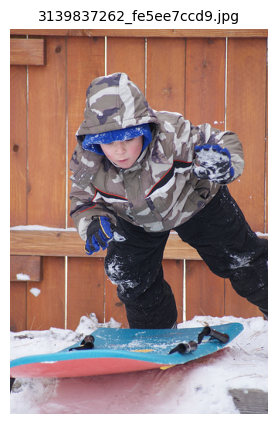


══════════════════════════════════════════════════════════════════════════════════════════
Image: 987907964_5a06a63609.jpg
Neutral: two dogs are running in a grassy yard. one dog is wearing a blue collar. the other dog is wearing a brown collar. the house is made of red wood.
──────────────────────────────────────────────────────────────────────────────────────────

  [B_ClipCap_EmotionAtEvery]
    humorous   GEN: black and white and brown and brown, chase!
               REF: the dogs are running in the yard, one sporting blue, the other brown; at least someone's accessorizing appropriately in front of that red wooden house.
    joyful     GEN: two dogs run through the green lawn.
               REF: with blue and brown collars flashing, two dogs bound through the grassy yard, pure, unadulterated joy against the backdrop of the red wooden house.
    romantic   GEN: the black and white and brown and the grassy.
               REF: two dogs, collars of blue and brown, dance through the

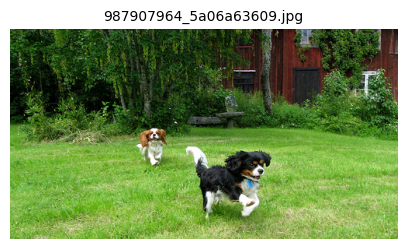


══════════════════════════════════════════════════════════════════════════════════════════
Image: 3245939062_8ffe1d2be5.jpg
Neutral: a man wearing sunglasses and a black baseball cap is pointing at a woman's head. the woman has a tattoo of a musical instrument on her neck. the man is wearing a black jacket and the woman is wearing a black and white checkered shirt. the background shows a city street.
──────────────────────────────────────────────────────────────────────────────────────────

  [B_ClipCap_EmotionAtEvery]
    humorous   GEN: striped shirt, the hat, aubergebrite.
               REF: man in sunglasses points at woman's neck tattoo; cap: baseball; jacket: black; the city street is unimpressed, as usual.
    joyful     GEN: striped shirt, the man, a silent echo.
               REF: the street buzzes with laughter! a man in sunglasses playfully points, a musical tattoo admired on a woman in cheerful checkered shirt.
    romantic   GEN: striped shirt, the striped patterned out

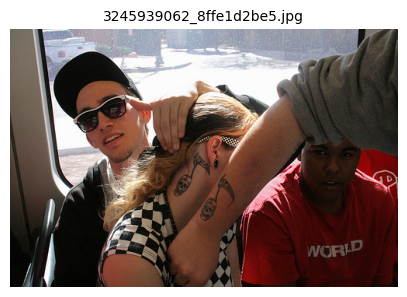


══════════════════════════════════════════════════════════════════════════════════════════
Image: 1718184338_5968d88edb.jpg
Neutral: two people stand on a rocky outcropping overlooking a river. one person wears a white helmet and an orange and black jacket, while the other wears a blue cap and a gray jacket. the river is a light blue-green color, and the surrounding landscape is rocky and dry.
──────────────────────────────────────────────────────────────────────────────────────────

  [B_ClipCap_EmotionAtEvery]
    humorous   GEN: two people stand together river, the blue sky!
               REF: two tourists are standing out on the rocky terrain, dressed for a hike. perhaps a picnic?
    joyful     GEN: two people stand alone in the river.
               REF: two people, one in orange and one in gray, joyfully stand on a rocky outcropping, admiring the blue-green river and arid landscape.
    romantic   GEN: two people stand on the water.
               REF: two figures stand togeth

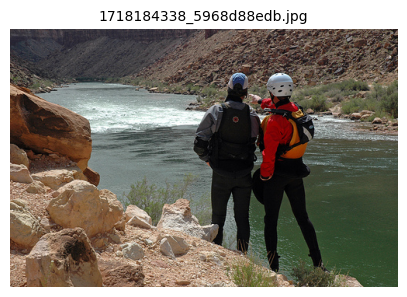


══════════════════════════════════════════════════════════════════════════════════════════
Image: 2721656220_5f4cda8bc1.jpg
Neutral: the woman is wearing a white t-shirt with a graphic design. she is holding a clear plastic mug with a brown liquid inside. she has dark hair and is wearing sunglasses.
──────────────────────────────────────────────────────────────────────────────────────────

  [B_ClipCap_EmotionAtEvery]
    humorous   GEN: the woman in a with woman shirt in the blur.
               REF: clear mug with brown liquid? sunglasses? graphic tee? clearly, this woman is either a barista or plotting something *very* caffeinated.
    joyful     GEN: the woman, a white shirt, the empty space.
               REF: smiling, the woman in the graphic tee holds a clear mug of brown liquid, sunglasses reflecting the bright, sunny spirit of the day!
    romantic   GEN: the woman in white tank top, a silent.
               REF: in the sunlight, the woman with dark hair and sunglasses gentl

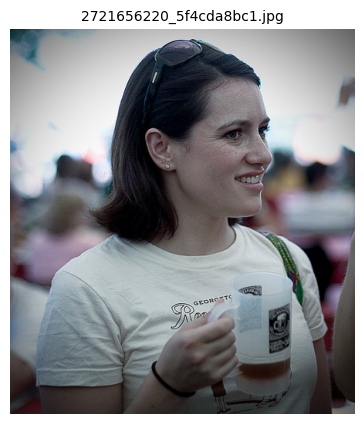


✅ Saved qualitative comparison → /kaggle/working/qualitative_log.json


In [29]:
import matplotlib.pyplot as plt

# Pick 3 random test images for side-by-side qualitative comparison
random.seed(0)
test_imgs = random.sample(test_df['image_id'].unique().tolist(), 5)

print("\n══════════ QUALITATIVE COMPARISON (3 random test images) ══════════\n")
qualitative_log = []   # for saving to file too

for img_id in test_imgs:
    print("\n" + "═" * 90)
    print(f"Image: {img_id}")
    sub = test_df[test_df['image_id'] == img_id]
    print(f"Neutral: {sub.iloc[0]['neutral_caption']}")
    print("─" * 90)

    feat = torch.load(
        os.path.join(FEATURE_DIR, f"{img_id.rsplit('.', 1)[0]}.pt"),
        weights_only=True
    ).unsqueeze(0).to(device)

    img_log = {'image_id': img_id, 'neutral': sub.iloc[0]['neutral_caption'], 'outputs': {}}

    for model_name, model in trained_models.items():
        print(f"\n  [{model_name}]")
        img_log['outputs'][model_name] = {}
        for emo in EMOTIONS:
            emo_id  = torch.tensor([EMOTION2ID[emo]], device=device)
            text    = decode_one(model, feat, emo_id, beam_size=4)
            gt_row  = sub[sub['emotion'] == emo]
            gt      = gt_row.iloc[0]['emotion_caption'] if len(gt_row) else ''
            print(f"    {emo:9s}  GEN: {text}")
            if gt:
                print(f"               REF: {gt}")
            img_log['outputs'][model_name][emo] = {'gen': text, 'ref': gt}

    qualitative_log.append(img_log)

    # Show the image
    try:
        img = Image.open(os.path.join(IMG_BASE_DIR, img_id)).convert('RGB')
        plt.figure(figsize=(5, 5))
        plt.imshow(img); plt.axis('off'); plt.title(img_id, fontsize=10)
        plt.show()
    except Exception as e:
        print(f"  (couldn't display image: {e})")

with open(f'{WORKING_DIR}/qualitative_log.json', 'w') as f:
    json.dump(qualitative_log, f, indent=2)
print(f"\n✅ Saved qualitative comparison → {WORKING_DIR}/qualitative_log.json")


### Training curves

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Training Diagnostics — Both Tracks', fontsize=13)

# Track A losses
track_a_hist = {n: h for n, h in histories.items() if n.startswith('A')}
track_b_hist = {n: h for n, h in histories.items() if n.startswith('B')}

for ax_row, (label, group) in enumerate([
    ('Track A (LSTM)',    track_a_hist),
    ('Track B (ClipCap)', track_b_hist),
]):
    for name, h in group.items():
        gap = [v - t for t, v in zip(h['train'], h['val'])]
        axes[ax_row, 0].plot(h['train'], label=name, alpha=0.8)
        axes[ax_row, 1].plot(h['val'],   label=name, alpha=0.8)
        axes[ax_row, 2].plot(gap,        label=name, alpha=0.8)
    axes[ax_row, 0].set(title=f'{label} — Train Loss', xlabel='Epoch', ylabel='loss')
    axes[ax_row, 1].set(title=f'{label} — Val Loss',   xlabel='Epoch', ylabel='loss')
    axes[ax_row, 2].axhline(0, color='black', linestyle='--', lw=0.6)
    axes[ax_row, 2].set(title=f'{label} — Val − Train Gap', xlabel='Epoch')
    for c in range(3):
        axes[ax_row, c].legend(fontsize=7)

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/training_curves.png', dpi=120)
plt.show()

print("\nFinal val−train gap by model:")
for name, h in histories.items():
    if not h['val']:
        continue
    gap  = h['val'][-1] - h['train'][-1]
    flag = '⚠️  overfit' if gap > 0.6 else '✅'
    print(f"  {name:30s}: gap={gap:+.4f}  best_val={min(h['val']):.4f}  {flag}")


### Save artifacts

In [ ]:
# Save histories + BLEU pickles for the report
with open(f'{WORKING_DIR}/training_histories.pkl', 'wb') as f:
    pickle.dump(histories, f)
with open(f'{WORKING_DIR}/bleu_results.pkl', 'wb') as f:
    pickle.dump({'overall': bleu_results, 'per_emotion': bleu_per_emo}, f)

print("\n✅ Saved files in working dir:")
for fname in sorted(os.listdir(WORKING_DIR)):
    fp = os.path.join(WORKING_DIR, fname)
    if os.path.isfile(fp):
        sz = os.path.getsize(fp)
        if sz > 1024:
            print(f"   {fname:46s}  {sz/1e6:7.2f} MB")
        else:
            print(f"   {fname:46s}  {sz} B")


## 🩺 Troubleshooting Reference

| Symptom | Most likely cause | First thing to try |
|---|---|---|
| Track A Stage A val loss stuck around 5.0 | Vocab too big / LR too high | Drop `MIN_TOKEN_FREQ` to 2 in Notebook 2, or `LSTM_LR_STAGE_A=2e-4` |
| Track A Stage B BLEU-4 < 0.02 across all variants | Stage A weights didn't transfer | Check `transferred N tensors` log; should be > 5 per variant |
| Track A captions still ungrammatical | Architectural ceiling | Track B is the answer — that's why we built it |
| Track B val loss stuck around 5–6 | LoRA not actually training | Print `n_train` from `train_clipcap` — should be > 500K |
| Track B captions are grammatical but ignore image | Visual prefix not being attended to | Bump `PREFIX_LEN` to 16, retrain |
| Track B captions are grammatical, grounded, but ignore emotion | Emotion signal too weak | For B2/B3, increase `LSTM_EMO_DIM` to 128 |
| Beam search slow | Test set × beam × max_len is large | Pass `n_max=200` to `compute_bleu` for a quick estimate |
| OOM during Track B | GPT-2 + prefix too heavy on T4 | Reduce `CC_BATCH_SIZE` to 16 |
| Both tracks identical-looking ablation rankings | Good news — confirms the ablation is robust to architecture | Report this in conclusion |


## 📦 What you have now

A `/kaggle/working/` directory with:

- `bleu_overall.csv` / `bleu_per_emotion.csv` — the headline tables for your report
- `bleu_results.pkl` / `training_histories.pkl` — for any further analysis
- `qualitative_log.json` — sample outputs from all 8 models on 3 test images
- `training_curves.png` — both tracks side by side
- 8 `.pt` checkpoints — one per trained model
- 1 `.pt` for the Stage-A neutral pretrain (initialiser for Track A's Stage B)

## Recommended report structure

1. **Method** — describe the proposal (Track A) and the strengthened pretrained-LM variant (Track B)
2. **Track A ablation** — show the 4 LSTM variants ranked by BLEU-4. Discuss which conditioning strategy wins (likely Emotion@Every or @Start) and why CrossAttention overfits.
3. **Track B ablation** — same table for ClipCap. Note that the **same conditioning ranking** appears at much higher absolute BLEU.
4. **Qualitative results** — picked outputs from the best Track B model, showing 5 emotional variants of the same image.
5. **Conclusion** — Track A validates the ablation hypothesis from the proposal; Track B shows that with a pretrained LM, the same ablation produces grammatically clean, emotionally distinct, visually grounded captions.
